# **TV1**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc bộ dữ liệu House Prices
df = pd.read_csv("train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [20]:
# 2. Xem số dòng và số cột của dataset
print(f"Kích thước tập dữ liệu (Dòng, Cột): {df.shape}")
df.shape

Kích thước tập dữ liệu (Dòng, Cột): (1460, 81)


(1460, 81)

In [21]:
# 3. Xem trước 5 dòng đầu tiên của tập dữ liệu
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
# 4. Xem thông tin kiểu dữ liệu (Dtype) và dung lượng bộ nhớ
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [23]:
# 5. TỔNG HỢP VÀ PHÂN LOẠI CÁC BIẾN (SUMMARY DATASET)

# Biến định danh và biến mục tiêu
id_col = 'Id'
target_col = 'SalePrice'

# Lấy danh sách các biến định lượng (Numerical) và định tính (Categorical)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Bỏ cột Id và SalePrice ra khỏi danh sách biến đặc trưng
feature_numerical = [c for c in numerical_cols if c not in [id_col, target_col]]

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("="*60)
print("BÁO CÁO TỔNG QUAN TẬP DỮ LIỆU")
print("="*60)
print(f"1. Số dòng: {df.shape[0]} dòng")
print(f"2. Số cột: {df.shape[1]} cột")
print(f"3. Biến mục tiêu (Target): '{target_col}' (Giá bán căn nhà bằng USD)")
print(f"4. Bài toán: Hồi quy (Regression) - Dự đoán giá trị liên tục SalePrice")
print(f"5. Số lượng biến Numerical (Định lượng): {len(feature_numerical)} biến")
print(f"6. Số lượng biến Categorical (Định tính): {len(categorical_cols)} biến")
print(f"7. Biến định danh: '{id_col}'")
print("="*60)

# Bảng tóm tắt số lượng biến theo kiểu dữ liệu
summary_type_df = pd.DataFrame({
    'Nhóm biến': ['Numerical (Định lượng)', 'Categorical (Định tính)', 'Target (Biến mục tiêu)', 'Identifier (Định danh)'],
    'Số lượng': [len(feature_numerical), len(categorical_cols), 1, 1]
})
summary_type_df

BÁO CÁO TỔNG QUAN TẬP DỮ LIỆU
1. Số dòng: 1460 dòng
2. Số cột: 81 cột
3. Biến mục tiêu (Target): 'SalePrice' (Giá bán căn nhà bằng USD)
4. Bài toán: Hồi quy (Regression) - Dự đoán giá trị liên tục SalePrice
5. Số lượng biến Numerical (Định lượng): 36 biến
6. Số lượng biến Categorical (Định tính): 43 biến
7. Biến định danh: 'Id'


,Nhóm biến,Số lượng
0,Numerical (Định lượng),36
1,Categorical (Định tính),43
2,Target (Biến mục tiêu),1
3,Identifier (Định danh),1


In [24]:
# In danh sách chi tiết các biến
print(f"--- DANH SÁCH {len(feature_numerical)} BIẾN NUMERICAL ---")
print(feature_numerical)

print(f"\n--- DANH SÁCH {len(categorical_cols)} BIẾN CATEGORICAL ---")
print(categorical_cols)

--- DANH SÁCH 36 BIẾN NUMERICAL ---
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

--- DANH SÁCH 43 BIẾN CATEGORICAL ---
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functio

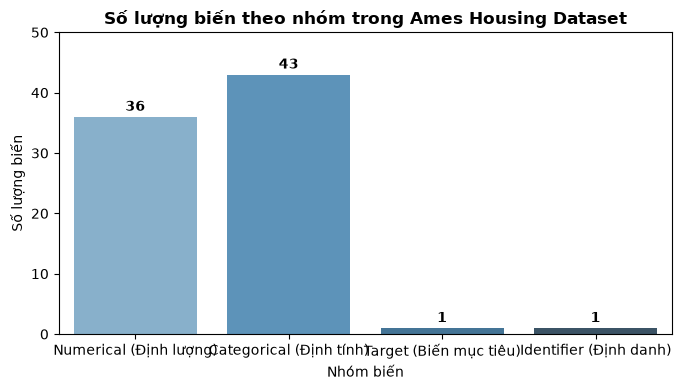

In [25]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x='Nhóm biến', 
    y='Số lượng', 
    data=summary_type_df, 
    hue='Nhóm biến', 
    palette='Blues_d', 
    legend=False
)

plt.title('Số lượng biến theo nhóm trong Ames Housing Dataset', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng biến')
for index, value in enumerate(summary_type_df['Số lượng']):
    plt.text(index, value + 1, str(value), ha='center', fontweight='bold')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

# **TV2**

In [26]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 1460
Số cột: 81


In [28]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [29]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": missing_percent
})

missing_table = missing_table[
    missing_table["Missing"] > 0
].sort_values("Percent", ascending=False)

missing_table

,Missing,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [30]:
numerical = df.select_dtypes(include=np.number)

print("Số biến numerical:", numerical.shape[1])
print(numerical.columns.tolist())

Số biến numerical: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [31]:
numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [32]:
df[["LotArea", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "SalePrice"]].describe().T

,count,mean,std,min,25%,50%,75%,max
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
GarageCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0


In [33]:
stats = numerical.describe().T

stats[["min", "50%", "max"]].sort_values("max", ascending=False)

,min,50%,max
SalePrice,34900.0,163000.0,755000.0
LotArea,1300.0,9478.5,215245.0
MiscVal,0.0,0.0,15500.0
TotalBsmtSF,0.0,991.5,6110.0
BsmtFinSF1,0.0,383.5,5644.0
GrLivArea,334.0,1464.0,5642.0
1stFlrSF,334.0,1087.0,4692.0
BsmtUnfSF,0.0,477.5,2336.0
2ndFlrSF,0.0,0.0,2065.0
YrSold,2006.0,2008.0,2010.0


In [34]:
for col in ["LotArea", "GrLivArea", "TotalBsmtSF", "1stFlrSF", "SalePrice"]:
    print(f"\n{col}")
    print(df[col].nlargest(5).values)


LotArea
[215245 164660 159000 115149  70761]

GrLivArea
[5642 4676 4476 4316 3627]

TotalBsmtSF
[6110 3206 3200 3138 3094]

1stFlrSF
[4692 3228 3138 2898 2633]

SalePrice
[755000 745000 625000 611657 582933]


# **TV3**

7. PHÂN TÍCH ĐƠN BIẾN - HISTOGRAM & BOXPLOT


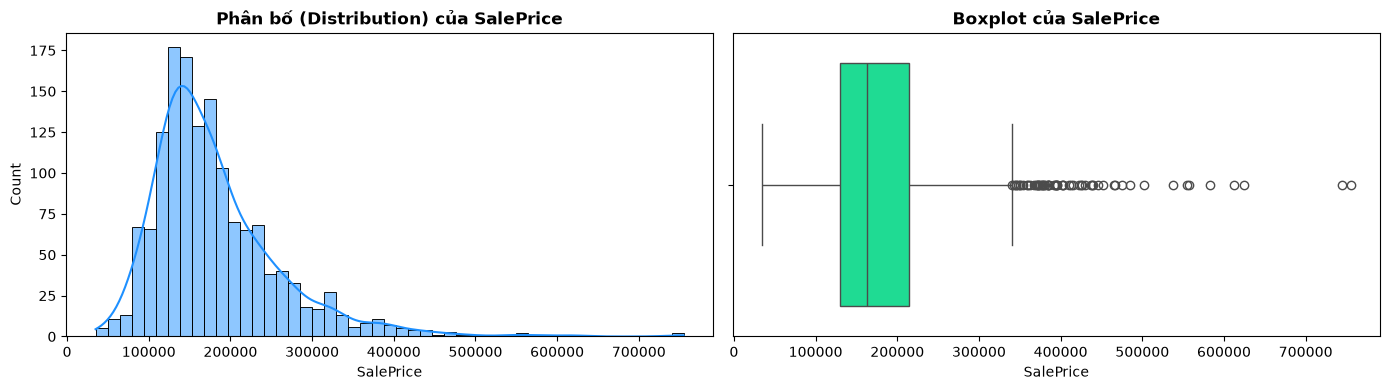

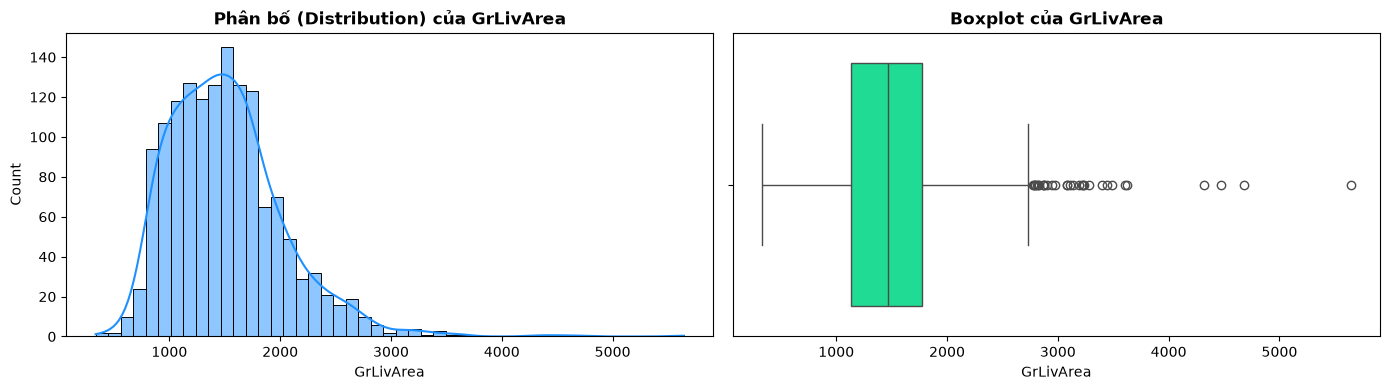

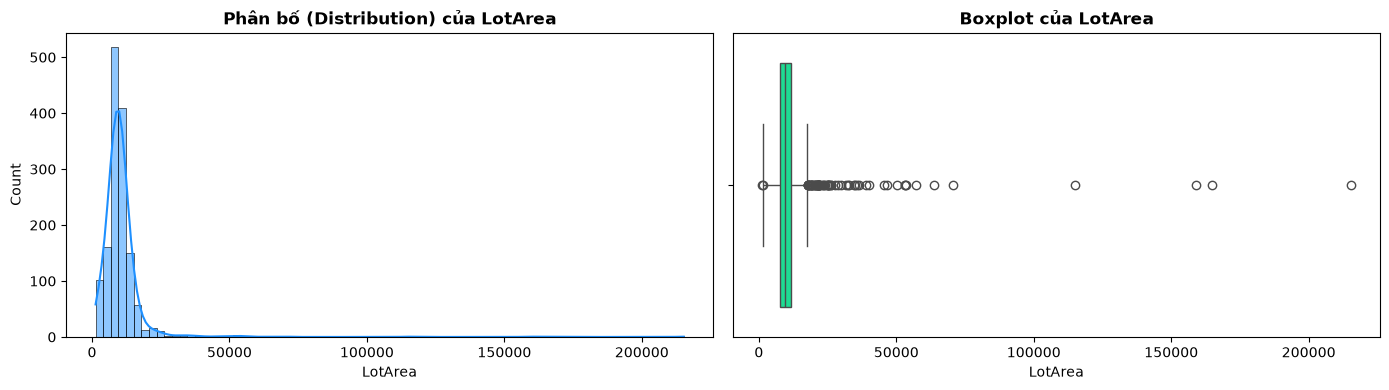

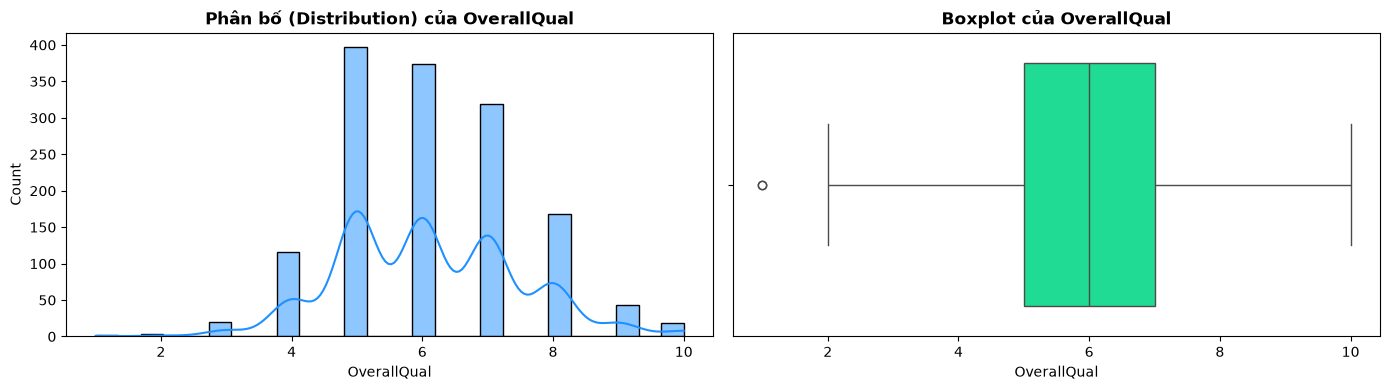

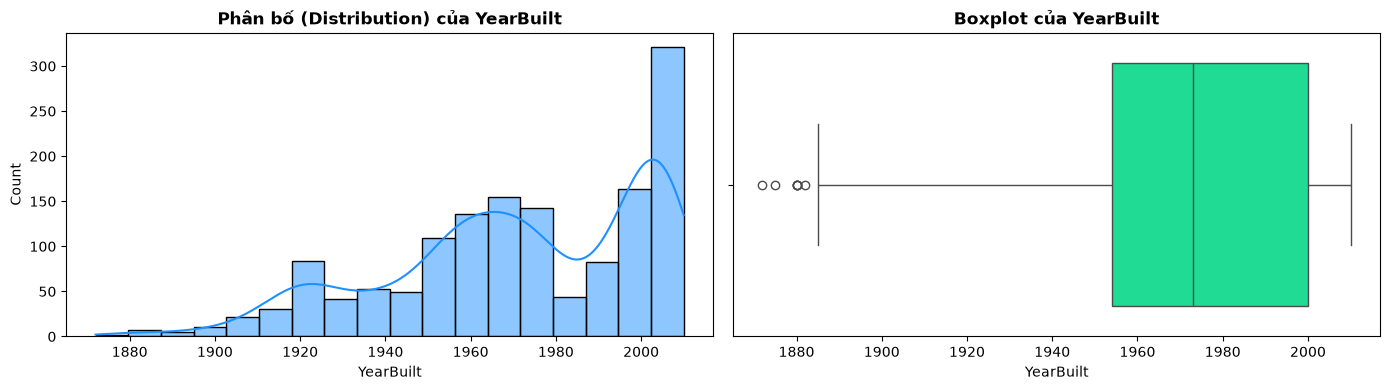

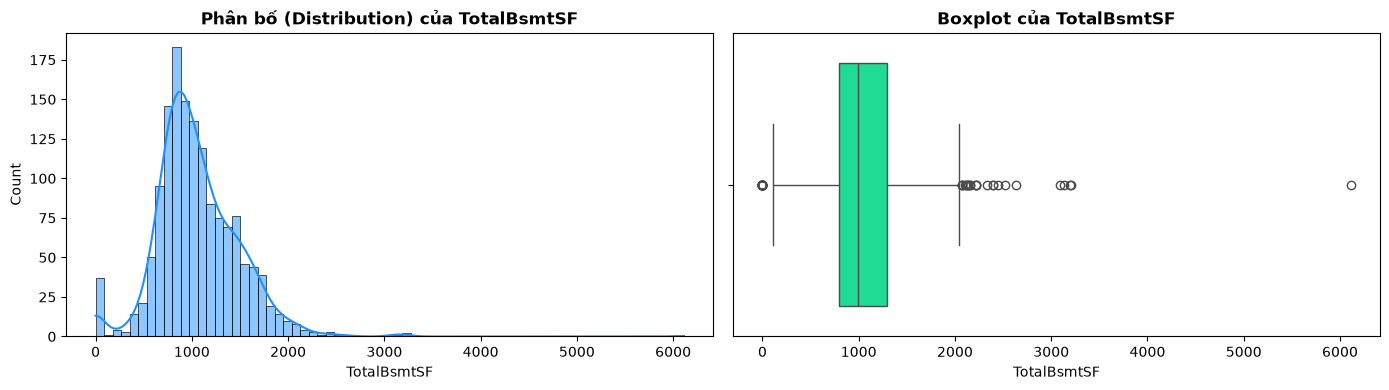

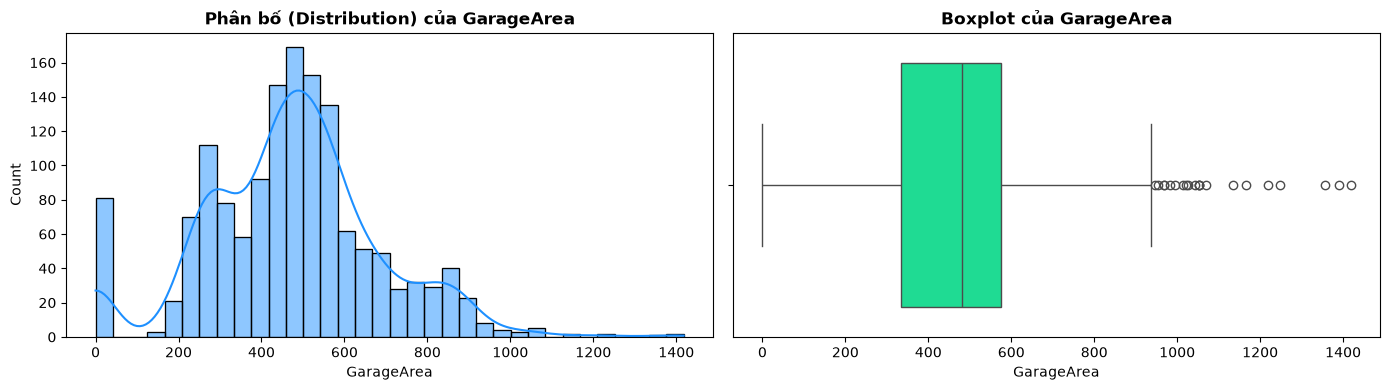

In [35]:
# 7. PHÂN TÍCH ĐƠN BIẾN DỰA TRÊN CÁC BIẾN QUAN TRỌNG (TV3 YÊU CẦU)
print("="*60)
print("7. PHÂN TÍCH ĐƠN BIẾN - HISTOGRAM & BOXPLOT")
print("="*60)

# Danh sách các biến cần tập trung khảo sát
important_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 
                  'YearBuilt', 'TotalBsmtSF', 'GarageArea']

for col in important_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Vẽ Histogram xem phân bố và độ lệch
    sns.histplot(df[col], kde=True, ax=axes[0], color='dodgerblue')
    axes[0].set_title(f'Phân bố (Distribution) của {col}', fontweight='bold')
    
    # Vẽ Boxplot xem các giá trị dị thường (outliers)
    sns.boxplot(x=df[col], ax=axes[1], color='mediumspringgreen')
    axes[1].set_title(f'Boxplot của {col}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# **TV4**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('train.csv')
df.shape

(1460, 81)

In [37]:
data = df.drop(columns=['Id', 'MSSubClass'])
print('Số biến số dùng để tính tương quan:', data.select_dtypes('number').shape[1])

Số biến số dùng để tính tương quan: 36


In [38]:
corr = data.corr(numeric_only=True)
corr

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
LotFrontage,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,0.132644,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,0.181133,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,0.114442,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,-0.495251,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,-0.209294,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378
BsmtUnfSF,0.132644,-0.002618,0.308159,-0.136841,0.149040,0.181133,0.114442,-0.495251,-0.209294,1.000000,...,-0.005316,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,0.034888,-0.041258,0.214479


In [39]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [40]:
corr_table = pd.DataFrame({
    'Pearson' : corr['SalePrice'],
    'Spearman': data.corr(numeric_only=True, method='spearman')['SalePrice']
}).drop('SalePrice')
corr_table = corr_table.reindex(corr_table['Pearson'].abs().sort_values(ascending=False).index)
corr_table.head(10).round(3)

,Pearson,Spearman
OverallQual,0.791,0.810
GrLivArea,0.709,0.731
GarageCars,0.640,0.691
GarageArea,0.623,0.649
TotalBsmtSF,0.614,0.603
1stFlrSF,0.606,0.575
FullBath,0.561,0.636
TotRmsAbvGrd,0.534,0.533
YearBuilt,0.523,0.653
YearRemodAdd,0.507,0.571


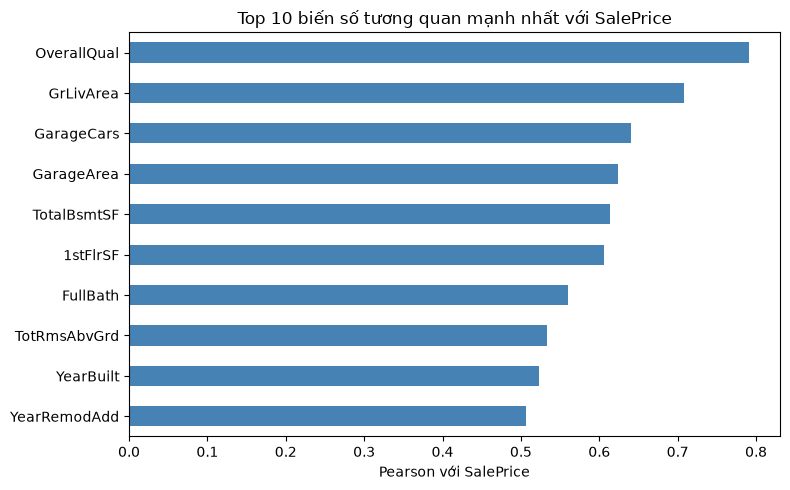

In [41]:
top = corr_table.head(10).iloc[::-1]
top['Pearson'].plot.barh(figsize=(8,5), color='steelblue')
plt.xlabel('Pearson với SalePrice'); plt.title('Top 10 biến số tương quan mạnh nhất với SalePrice')
plt.tight_layout(); plt.savefig('fig_top_corr.png', dpi=130); plt.show()

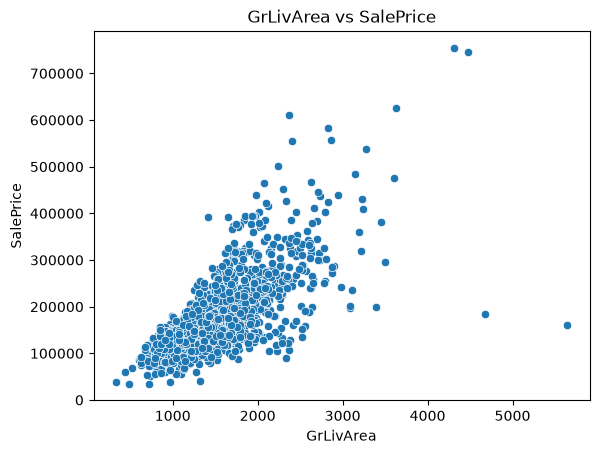

In [42]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.savefig('fig_scatter_grlivarea.png', dpi=130); plt.show()

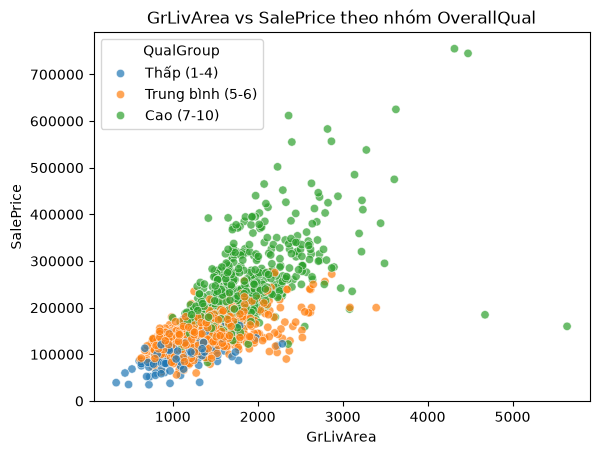

In [43]:
df['QualGroup'] = pd.cut(df['OverallQual'], bins=[0,4,6,10],
                         labels=['Thấp (1-4)', 'Trung bình (5-6)', 'Cao (7-10)'])
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='QualGroup', alpha=0.7)
plt.title('GrLivArea vs SalePrice theo nhóm OverallQual')
plt.savefig('fig_scatter_grlivarea_hue.png', dpi=130); plt.show()

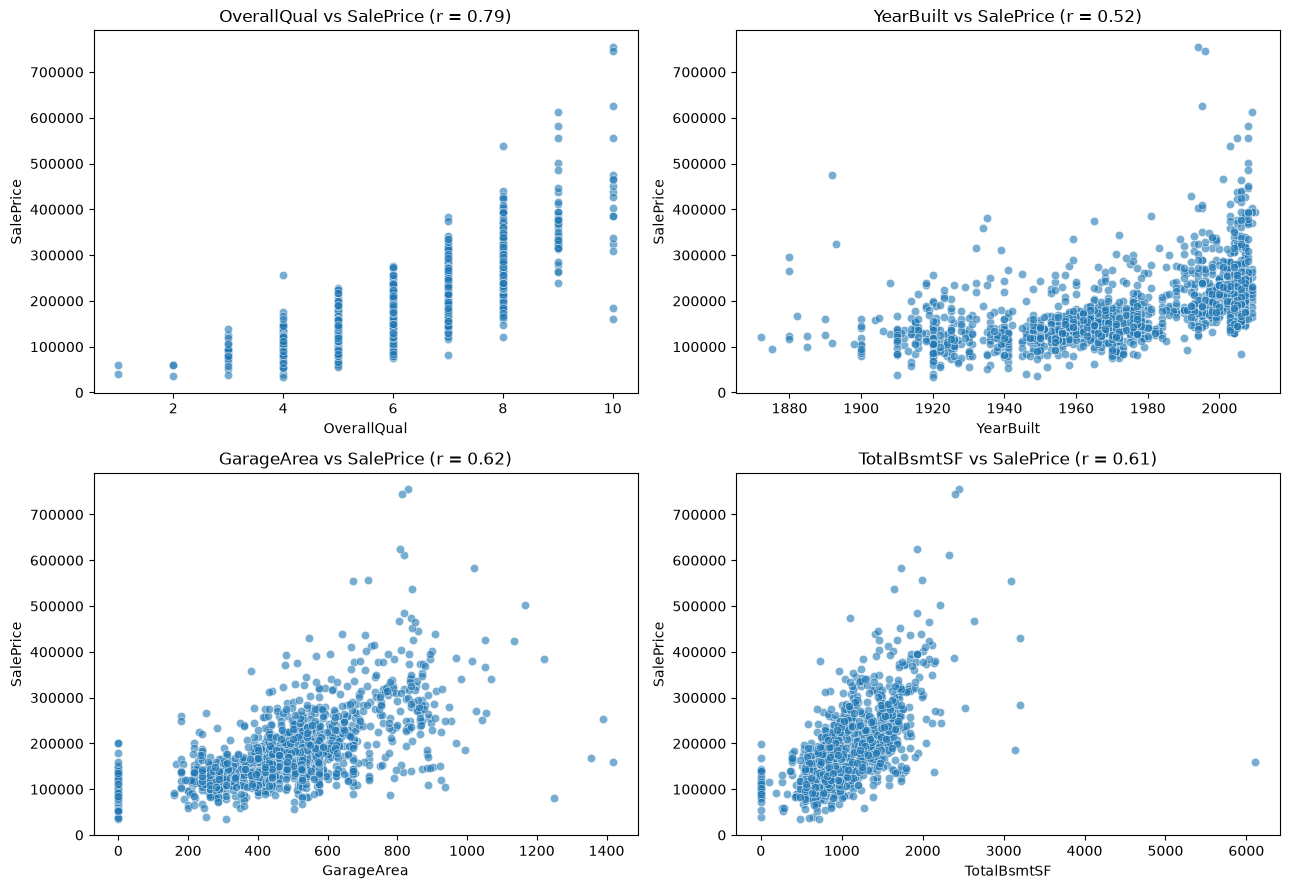

In [44]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for a, f in zip(ax.ravel(), ['OverallQual', 'YearBuilt', 'GarageArea', 'TotalBsmtSF']):
    sns.scatterplot(data=df, x=f, y='SalePrice', ax=a, alpha=0.6)
    a.set_title(f'{f} vs SalePrice (r = {df[f].corr(df["SalePrice"]):.2f})')
plt.tight_layout(); plt.savefig('fig_scatter_4.png', dpi=130); plt.show()

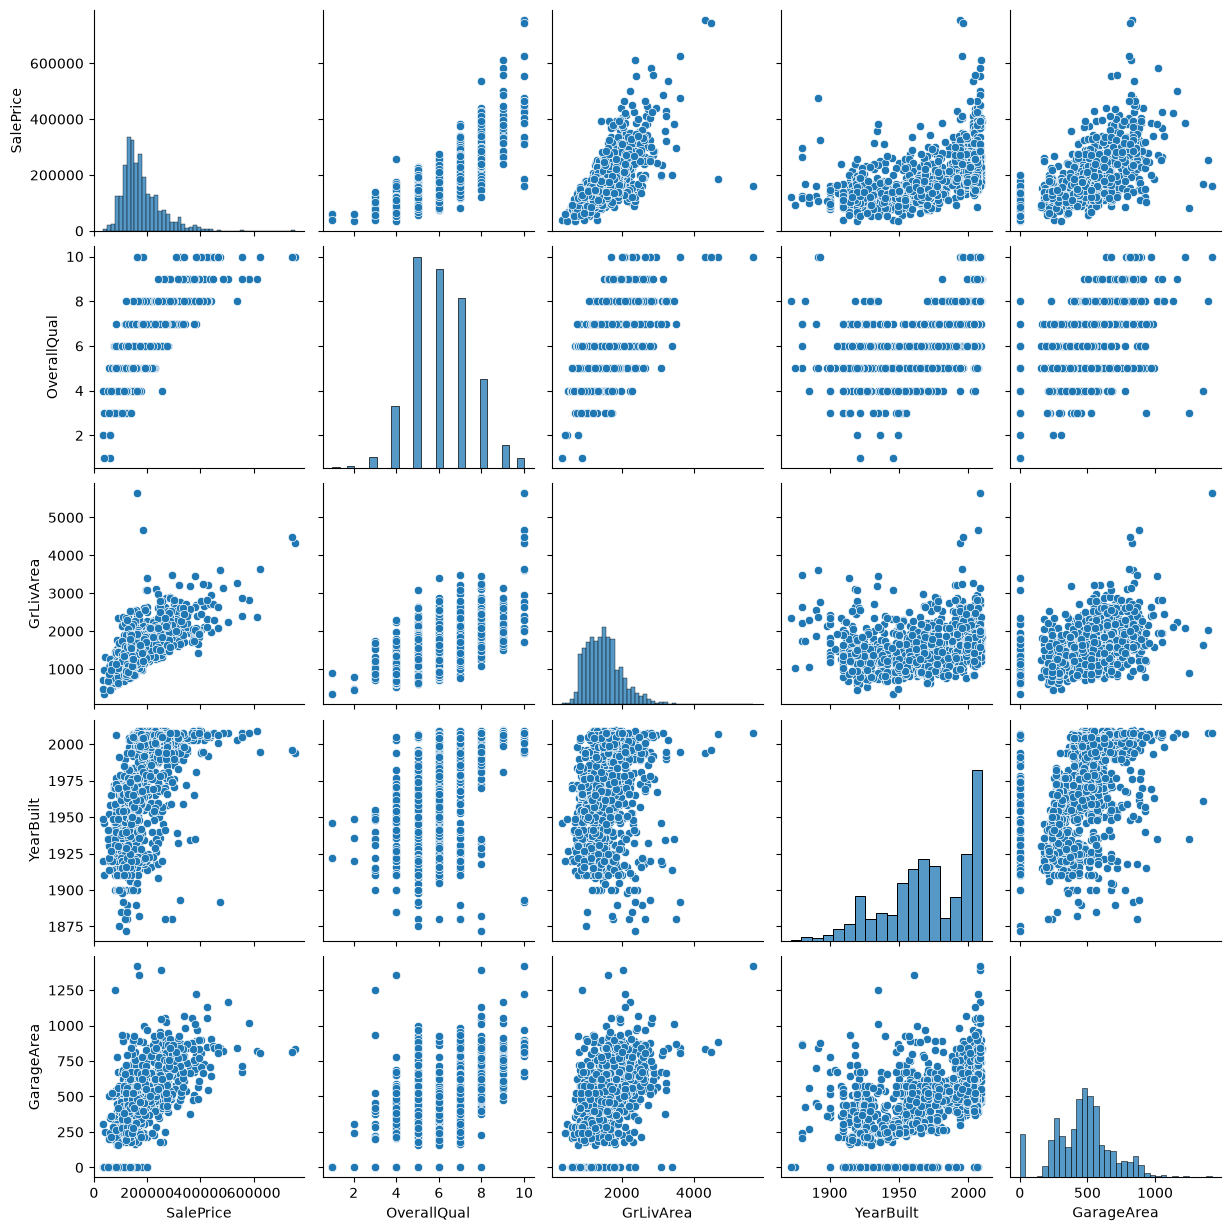

In [45]:
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'GarageArea']
sns.pairplot(df[cols])
plt.savefig('fig_pairplot.png', dpi=110); plt.show()

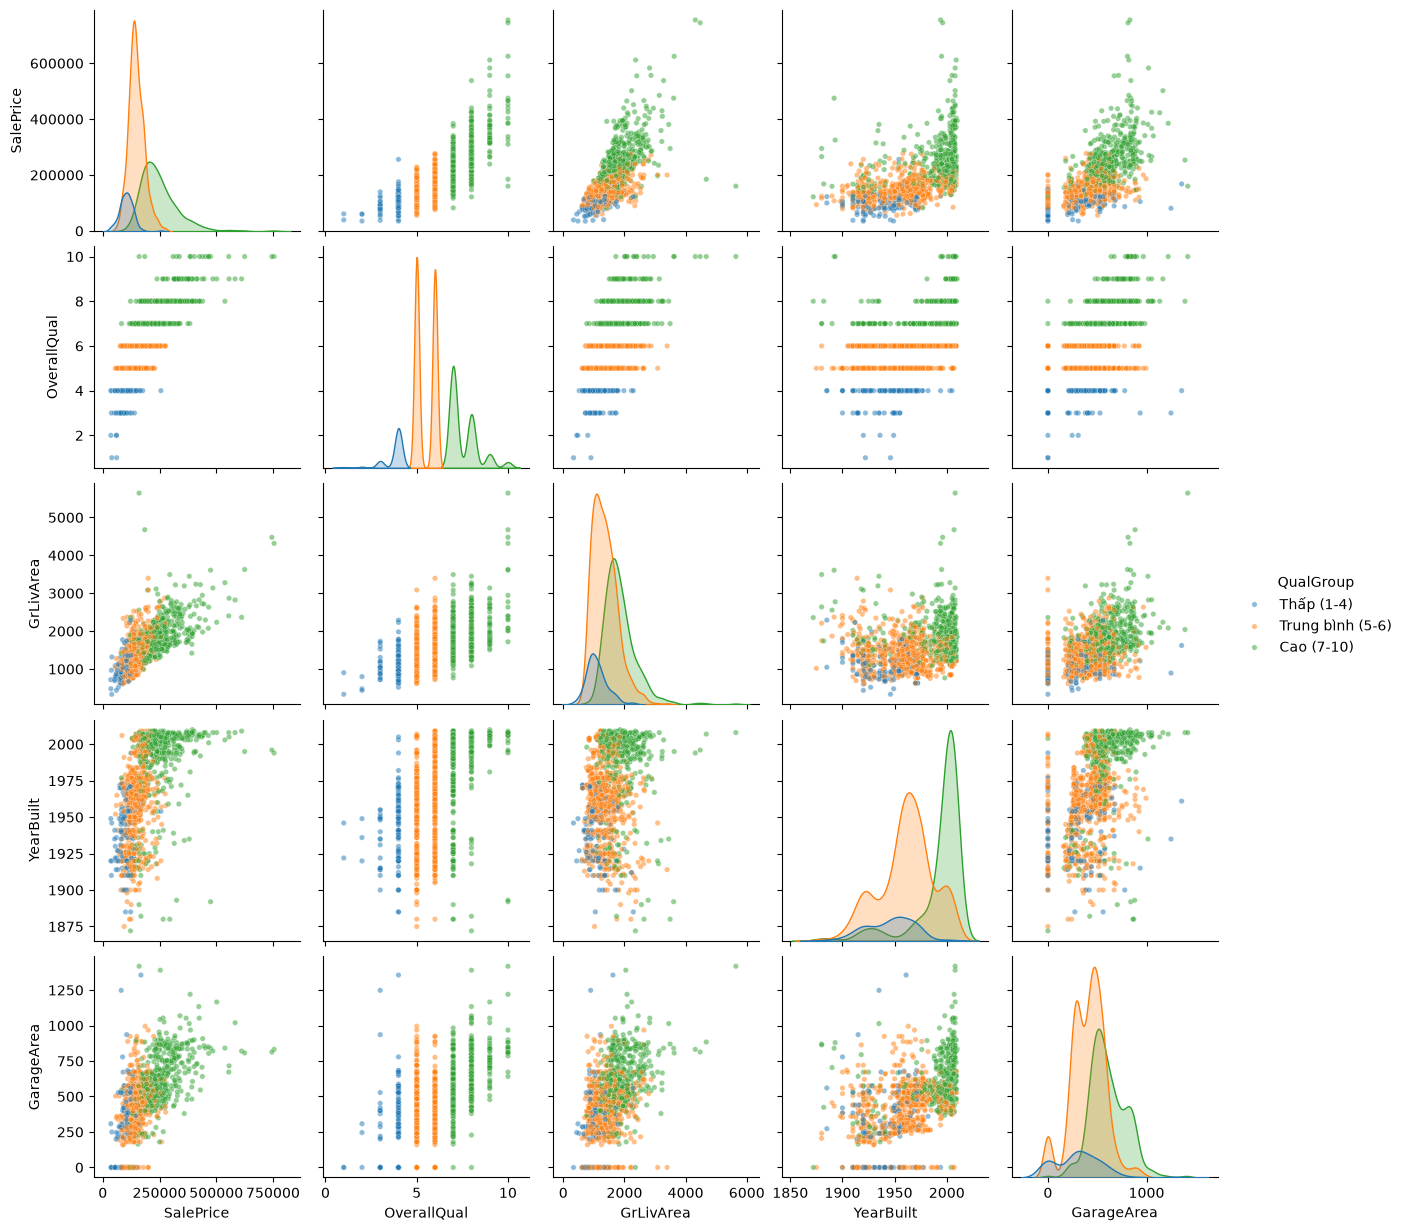

In [46]:
sns.pairplot(df[cols + ['QualGroup']], hue='QualGroup', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15})
plt.savefig('fig_pairplot_hue.png', dpi=110); plt.show()

In [47]:
df.groupby('QualGroup')[cols].median().round(0)

,SalePrice,OverallQual,GrLivArea,YearBuilt,GarageArea
QualGroup,,,,,
Thấp (1-4),105000.0,4.0,1040.0,1949.0,296.0
Trung bình (5-6),143000.0,5.0,1302.0,1963.0,431.0
Cao (7-10),230000.0,7.0,1734.0,2002.0,576.0


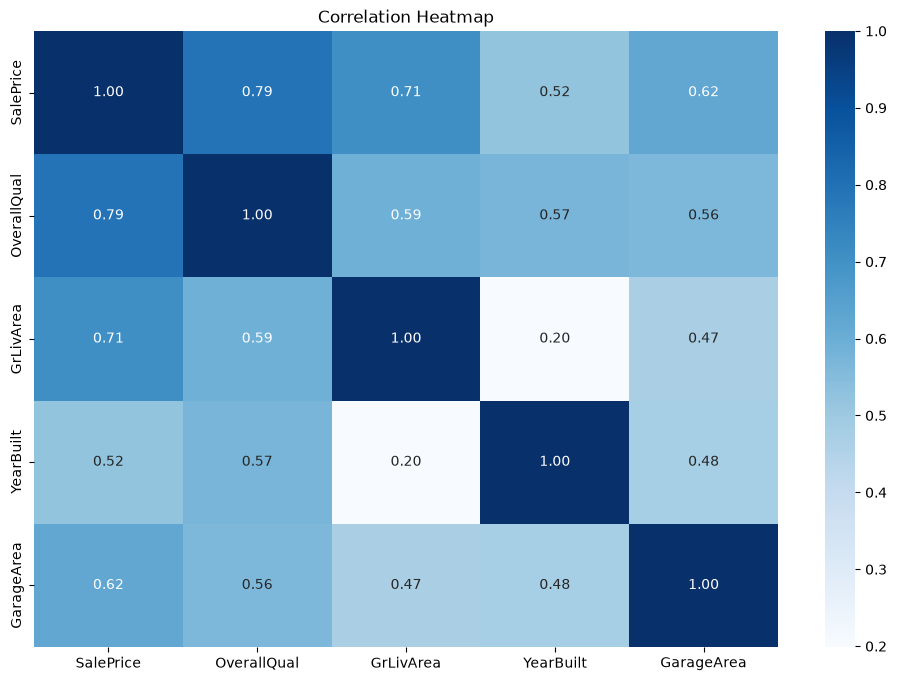

In [48]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.savefig('fig_heatmap.png', dpi=130); plt.show()

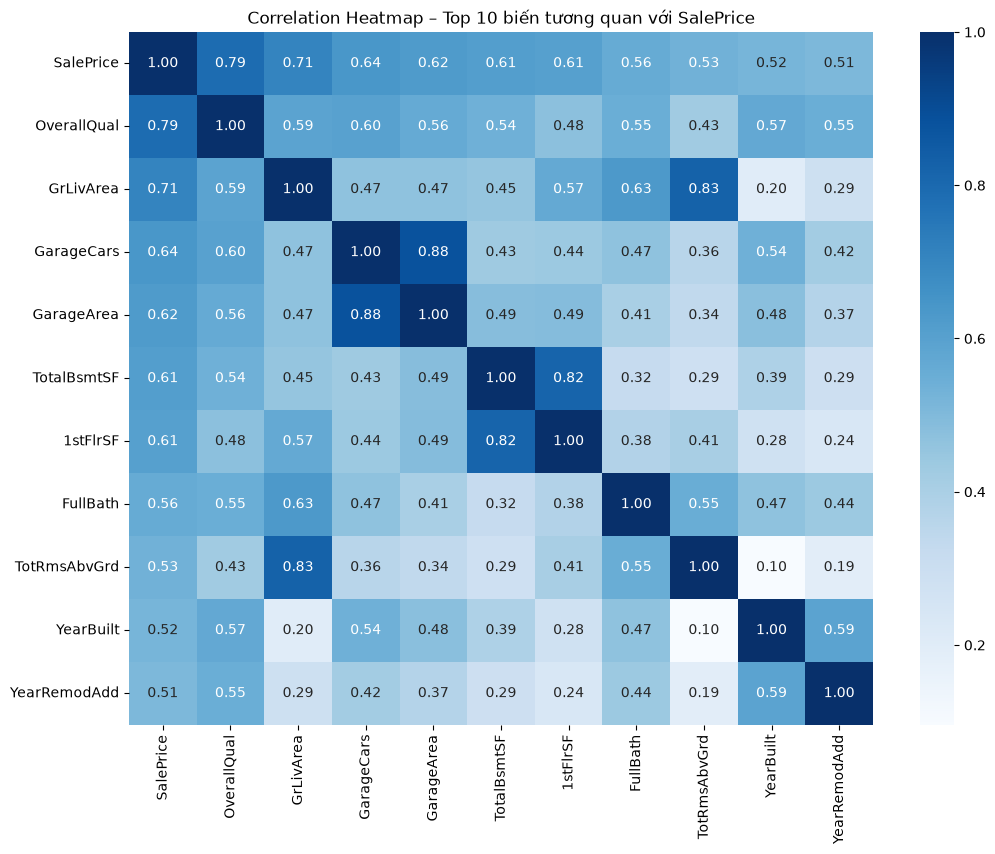

In [49]:
top10 = corr_table.head(10).index.tolist()
plt.figure(figsize=(12, 9))
sns.heatmap(data[['SalePrice'] + top10].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap – Top 10 biến tương quan với SalePrice')
plt.savefig('fig_heatmap_top10.png', dpi=130); plt.show()

In [50]:
# Các cặp biến đầu vào có |r| > 0.7
c = data[top10].corr()
pairs = [(a, b, round(c.loc[a, b], 3)) for i, a in enumerate(top10) for b in top10[i+1:] if abs(c.loc[a, b]) > 0.7]
pd.DataFrame(pairs, columns=['Biến A', 'Biến B', 'Pearson']).sort_values('Pearson', ascending=False)

,Biến A,Biến B,Pearson
1,GarageCars,GarageArea,0.882
0,GrLivArea,TotRmsAbvGrd,0.825
2,TotalBsmtSF,1stFlrSF,0.820


# **TV5**

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
target_col = 'SalePrice'
print("Kích thước:", df.shape)

Kích thước: (1460, 81)


In [52]:
# Đếm ngoại lệ dựa trên phương pháp IQR
outlier_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

rows = []
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append({
        'Biến': col,
        'Giới hạn dưới': round(low, 1),
        'Giới hạn trên': round(high, 1),
        'Max': df[col].max(),
        'Số ngoại lệ': n_out,
        'Tỷ lệ (%)': round(n_out / len(df) * 100, 2),
        'Skewness': round(df[col].skew(), 2)
    })

iqr_df = pd.DataFrame(rows).sort_values('Số ngoại lệ', ascending=False)
iqr_df

,Biến,Giới hạn dưới,Giới hạn trên,Max,Số ngoại lệ,Tỷ lệ (%),Skewness
2,LotArea,1481.5,17673.5,215245,69,4.73,12.21
0,SalePrice,3937.5,340037.5,755000,61,4.18,1.88
3,TotalBsmtSF,42.0,2052.0,6110,61,4.18,1.52
1,GrLivArea,158.6,2747.6,5642,31,2.12,1.37
4,GarageArea,-27.8,938.2,1418,21,1.44,0.18
5,1stFlrSF,118.1,2155.1,4692,20,1.37,1.38


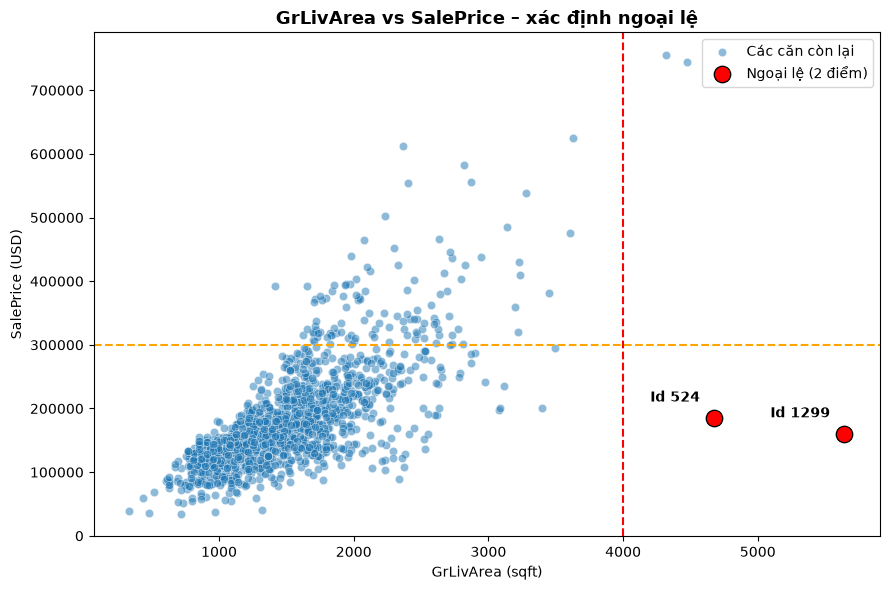

In [53]:
# Vẽ biểu đồ scatter để xác định ngoại lệ dựa trên GrLivArea và SalePrice
outliers = df[(df['GrLivArea'] > 4000) & (df[target_col] < 300000)]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='GrLivArea', y=target_col, alpha=0.5, label='Các căn còn lại')
sns.scatterplot(data=outliers, x='GrLivArea', y=target_col, color='red', s=140,
                edgecolor='k', label=f'Ngoại lệ ({len(outliers)} điểm)')

for _, r in outliers.iterrows():
    plt.annotate(f"Id {int(r['Id'])}", (r['GrLivArea'], r[target_col]),
                 textcoords='offset points', xytext=(-10, 12), ha='right', fontweight='bold')

plt.axvline(4000, color='red', linestyle='--', linewidth=1.5)
plt.axhline(300000, color='orange', linestyle='--', linewidth=1.5)
plt.title('GrLivArea vs SalePrice – xác định ngoại lệ', fontsize=13, fontweight='bold')
plt.xlabel('GrLivArea (sqft)')
plt.ylabel('SalePrice (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# In ra danh sách các ngoại lệ
detail_cols = ['Id', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'OverallQual',
               'Neighborhood', 'SaleCondition', 'SalePrice']

print("A. Diện tích rất lớn (GrLivArea > 4000):")
display(df.loc[df['GrLivArea'] > 4000, detail_cols])

print("B. Giá rất cao (SalePrice > 500000):")
display(df.loc[df[target_col] > 500000, detail_cols])

A. Diện tích rất lớn (GrLivArea > 4000):


,Id,GrLivArea,TotalBsmtSF,LotArea,OverallQual,Neighborhood,SaleCondition,SalePrice
523,524,4676,3138,40094,10,Edwards,Partial,184750
691,692,4316,2444,21535,10,NoRidge,Normal,755000
1182,1183,4476,2396,15623,10,NoRidge,Abnorml,745000
1298,1299,5642,6110,63887,10,Edwards,Partial,160000


B. Giá rất cao (SalePrice > 500000):


,Id,GrLivArea,TotalBsmtSF,LotArea,OverallQual,Neighborhood,SaleCondition,SalePrice
178,179,2234,2216,17423,9,StoneBr,Partial,501837
440,441,2402,3094,15431,10,NridgHt,Normal,555000
691,692,4316,2444,21535,10,NoRidge,Normal,755000
769,770,3279,1650,53504,8,StoneBr,Normal,538000
803,804,2822,1734,13891,9,NridgHt,Partial,582933
898,899,2364,2330,12919,9,NridgHt,Partial,611657
1046,1047,2868,1992,16056,9,StoneBr,Partial,556581
1169,1170,3627,1930,35760,10,NoRidge,Normal,625000
1182,1183,4476,2396,15623,10,NoRidge,Abnorml,745000


In [55]:
# Loại bỏ các ngoại lệ và so sánh hệ số tương quan
df_clean = df.drop(index=outliers.index)

compare = pd.DataFrame({
    'Biến': ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'GarageArea'],
}).set_index('Biến')
compare['Pearson (gốc)'] = [df[c].corr(df[target_col]) for c in compare.index]
compare['Pearson (bỏ ngoại lệ)'] = [df_clean[c].corr(df_clean[target_col]) for c in compare.index]
compare['Chênh lệch'] = compare['Pearson (bỏ ngoại lệ)'] - compare['Pearson (gốc)']

print(f"Số dòng trước: {len(df)} | sau khi loại {len(outliers)} ngoại lệ: {len(df_clean)}")
compare.round(3)

Số dòng trước: 1460 | sau khi loại 2 ngoại lệ: 1458


,Pearson (gốc),Pearson (bỏ ngoại lệ),Chênh lệch
Biến,,,
GrLivArea,0.709,0.735,0.026
TotalBsmtSF,0.614,0.651,0.038
OverallQual,0.791,0.796,0.005
GarageArea,0.623,0.629,0.006


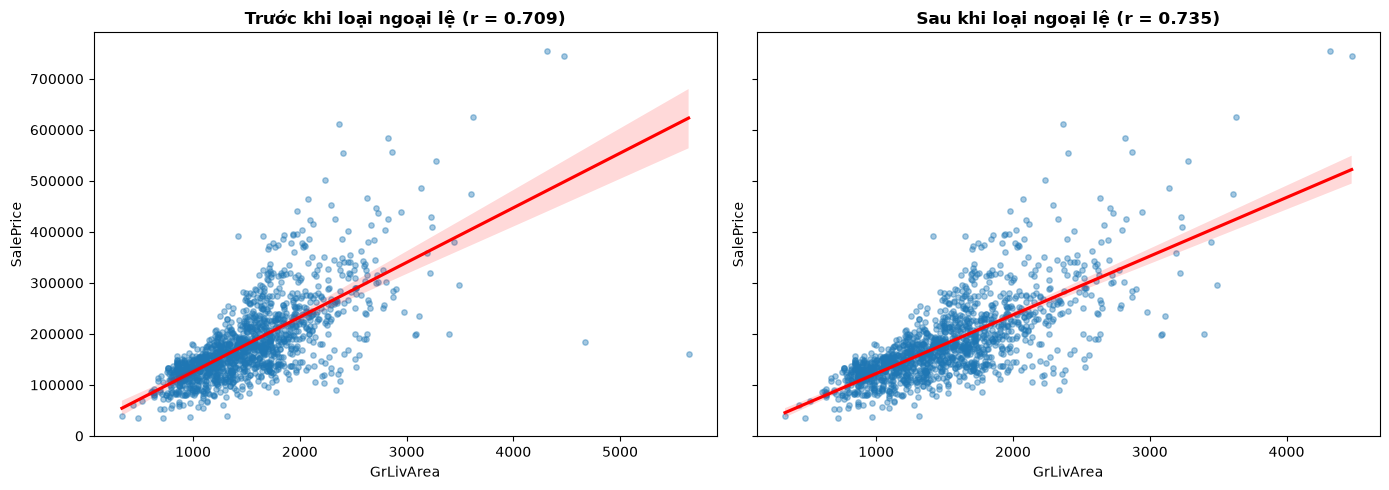

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title in zip(axes, [df, df_clean],
                           ['Trước khi loại ngoại lệ', 'Sau khi loại ngoại lệ']):
    sns.regplot(data=data, x='GrLivArea', y=target_col, ax=ax,
                scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'})
    r = data['GrLivArea'].corr(data[target_col])
    ax.set_title(f'{title} (r = {r:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

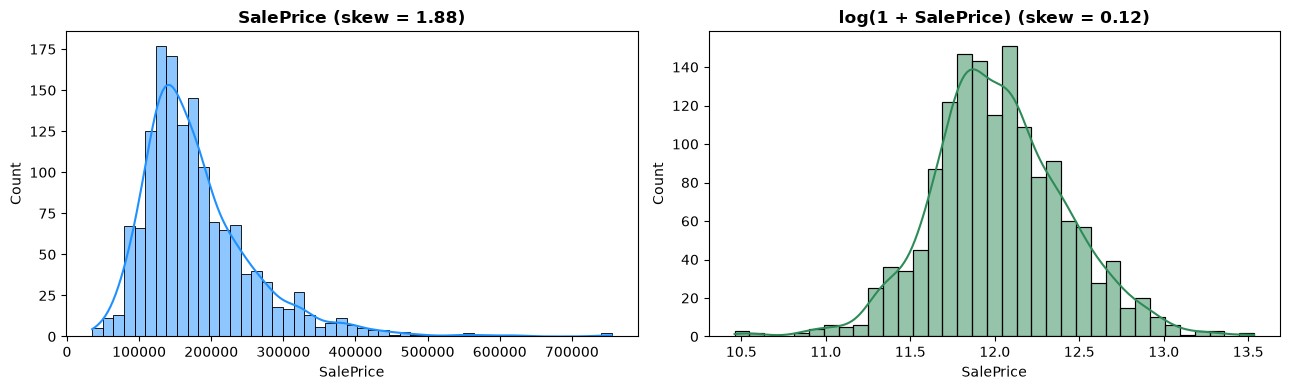

In [57]:
# Vẽ biểu đồ phân bố của SalePrice trước và sau khi loại bỏ ngoại lệ
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df[target_col], kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title(f'SalePrice (skew = {df[target_col].skew():.2f})', fontweight='bold')

sns.histplot(np.log1p(df[target_col]), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'log(1 + SalePrice) (skew = {np.log1p(df[target_col]).skew():.2f})', fontweight='bold')

plt.tight_layout()
plt.show()